# Теорема Котельникова — задание 20

В этом ноутбуке строятся:

- **1 период косинусоидального сигнала**
- его **амплитудный спектр**
- для частот сигнала **1 Гц** и **40 Гц**
- при частотах дискретизации **400 Гц**, **80 Гц**, **70 Гц**

Ноутбук оформлен так, чтобы наглядно показать:
- корректную дискретизацию,
- граничный случай по теореме Котельникова,
- эффект **алиасинга** при недостаточной частоте дискретизации.


## Идея

Для сигнала

\[
x(t) = \cos(2\pi f t)
\]

теорема Котельникова (Шеннона) требует:

\[
f_s \ge 2f_{max}
\]

где:
- \(f\) — частота сигнала,
- \(f_s\) — частота дискретизации.

В нашем задании особенно интересен сигнал **40 Гц**:

- при **400 Гц** — сильное превышение условия,
- при **80 Гц** — ровно граница Найквиста,
- при **70 Гц** — условие нарушено, возникает **наложение спектров (aliasing)**.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (11, 4.5)
plt.rcParams['axes.grid'] = True
plt.rcParams['font.size'] = 12

def generate_one_period(f_signal, fs):
    """Возвращает временную ось и 1 период дискретизированного косинуса."""
    T = 1 / f_signal
    N = max(2, int(round(fs * T)))  # число отсчетов примерно на 1 период
    t = np.arange(N) / fs
    x = np.cos(2 * np.pi * f_signal * t)
    return t, x, T, N

def amplitude_spectrum(x, fs):
    """Односторонний амплитудный спектр."""
    N = len(x)
    X = np.fft.rfft(x)
    freqs = np.fft.rfftfreq(N, d=1/fs)
    A = np.abs(X) / N
    if N > 1:
        A[1:-1] *= 2
    return freqs, A

def alias_frequency(f, fs):
    """Частота алиасинга в диапазоне [0, fs/2]."""
    k = int(np.round(f / fs))
    f_alias = abs(f - k * fs)
    if f_alias > fs / 2:
        f_alias = fs - f_alias
    return f_alias

def plot_case(f_signal, fs):
    t, x, T, N = generate_one_period(f_signal, fs)
    freqs, A = amplitude_spectrum(x, fs)
    nyquist = fs / 2
    f_alias = alias_frequency(f_signal, fs)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

    # Временная область
    axes[0].stem(t, x, basefmt=' ')
    axes[0].plot(t, x, alpha=0.7)
    axes[0].set_title(f'Сигнал: f = {f_signal} Гц, fs = {fs} Гц')
    axes[0].set_xlabel('t, c')
    axes[0].set_ylabel('x[n]')
    axes[0].set_xlim(left=0)

    # Спектр
    axes[1].stem(freqs, A, basefmt=' ')
    axes[1].axvline(nyquist, linestyle='--', alpha=0.8, label=f'Найквист = {nyquist:.1f} Гц')
    axes[1].set_title('Амплитудный спектр')
    axes[1].set_xlabel('f, Гц')
    axes[1].set_ylabel('|X(f)|')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    print(f'Частота сигнала: {f_signal} Гц')
    print(f'Частота дискретизации: {fs} Гц')
    print(f'Период сигнала: {T:.5f} c')
    print(f'Число отсчётов на период: {N}')
    print(f'Частота Найквиста: {nyquist:.2f} Гц')
    print(f'Наблюдаемая частота (alias): {f_alias:.2f} Гц')


## 1) Частота дискретизации 400 Гц

Это комфортный режим дискретизации для обеих частот сигнала.


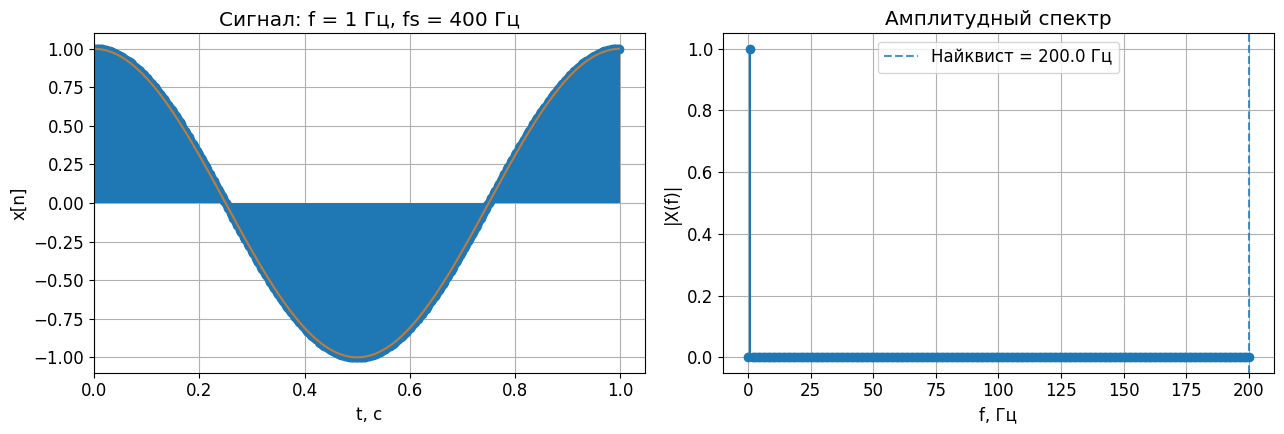

Частота сигнала: 1 Гц
Частота дискретизации: 400 Гц
Период сигнала: 1.00000 c
Число отсчётов на период: 400
Частота Найквиста: 200.00 Гц
Наблюдаемая частота (alias): 1.00 Гц
--------------------------------------------------------------------------------


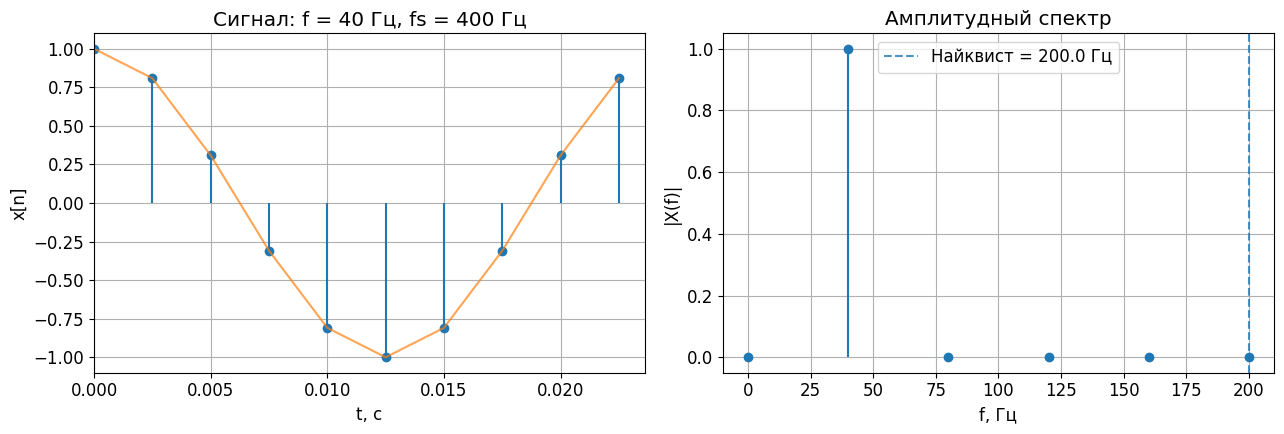

Частота сигнала: 40 Гц
Частота дискретизации: 400 Гц
Период сигнала: 0.02500 c
Число отсчётов на период: 10
Частота Найквиста: 200.00 Гц
Наблюдаемая частота (alias): 40.00 Гц
--------------------------------------------------------------------------------


In [2]:
for f_signal in [1, 40]:
    plot_case(f_signal, 400)
    print('-' * 80)


### Вывод для `fs = 400 Гц`

- Для **1 Гц** сигнал описывается очень подробно.
- Для **40 Гц** также выполняется условие \(f_s \gg 2f\), поэтому спектр отображается корректно.
- Алиасинга нет.


## 2) Частота дискретизации 80 Гц

Это особый случай для сигнала **40 Гц**, потому что:

\[
f_s = 2f = 80 \text{ Гц}
\]

То есть сигнал находится **ровно на границе Найквиста**.


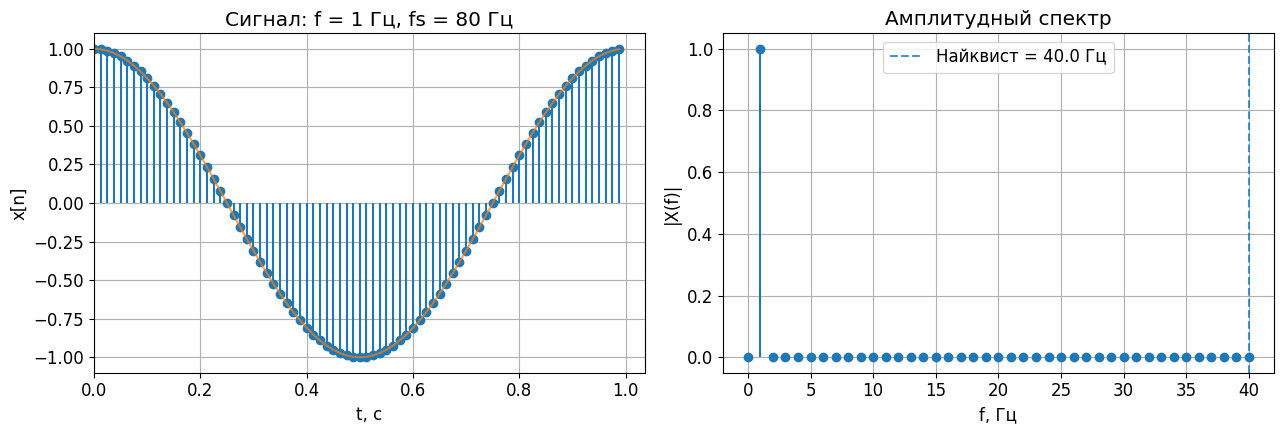

Частота сигнала: 1 Гц
Частота дискретизации: 80 Гц
Период сигнала: 1.00000 c
Число отсчётов на период: 80
Частота Найквиста: 40.00 Гц
Наблюдаемая частота (alias): 1.00 Гц
--------------------------------------------------------------------------------


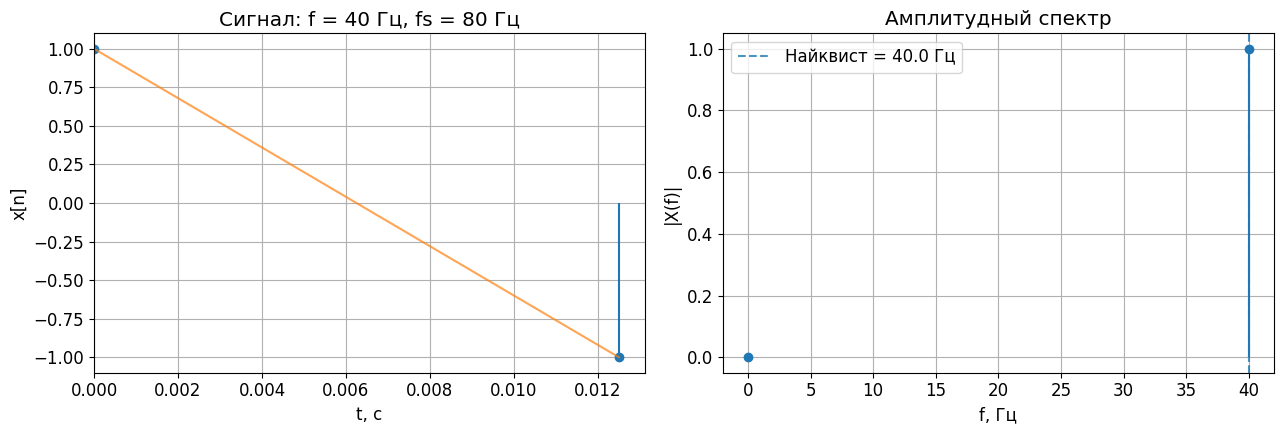

Частота сигнала: 40 Гц
Частота дискретизации: 80 Гц
Период сигнала: 0.02500 c
Число отсчётов на период: 2
Частота Найквиста: 40.00 Гц
Наблюдаемая частота (alias): 40.00 Гц
--------------------------------------------------------------------------------


In [3]:
for f_signal in [1, 40]:
    plot_case(f_signal, 80)
    print('-' * 80)


### Вывод для `fs = 80 Гц`

- Для **1 Гц** всё корректно.
- Для **40 Гц** выполняется только граничное условие.
- На границе Найквиста сигнал дискретизируется минимально возможным числом точек.
- Практически это неустойчивый режим для реальных измерений: малейший сдвиг частоты или фазы уже приводит к ошибкам.


## 3) Частота дискретизации 70 Гц

Теперь для сигнала **40 Гц** условие Котельникова нарушается:

\[
70 < 2 \cdot 40 = 80
\]

Поэтому должен появиться **алиасинг**.


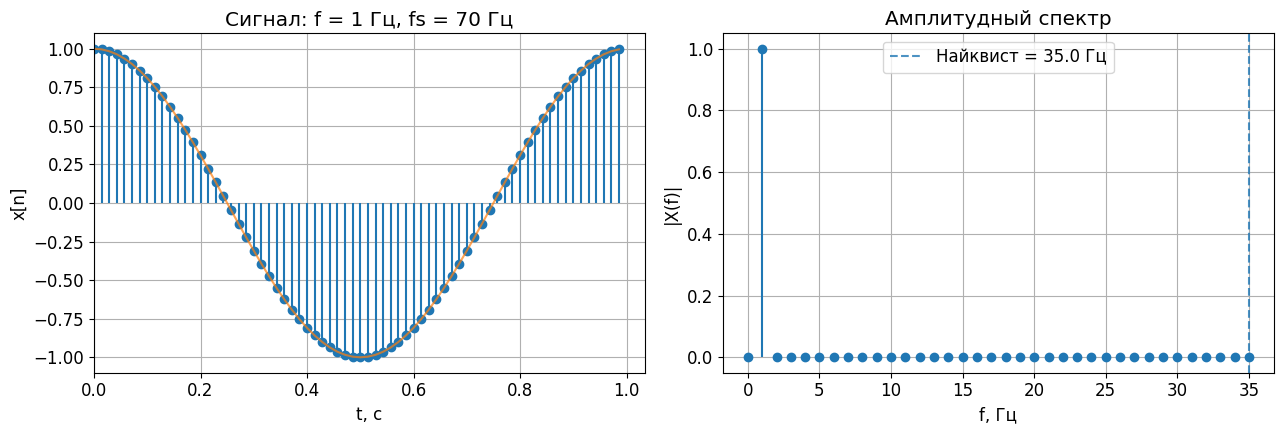

Частота сигнала: 1 Гц
Частота дискретизации: 70 Гц
Период сигнала: 1.00000 c
Число отсчётов на период: 70
Частота Найквиста: 35.00 Гц
Наблюдаемая частота (alias): 1.00 Гц
--------------------------------------------------------------------------------


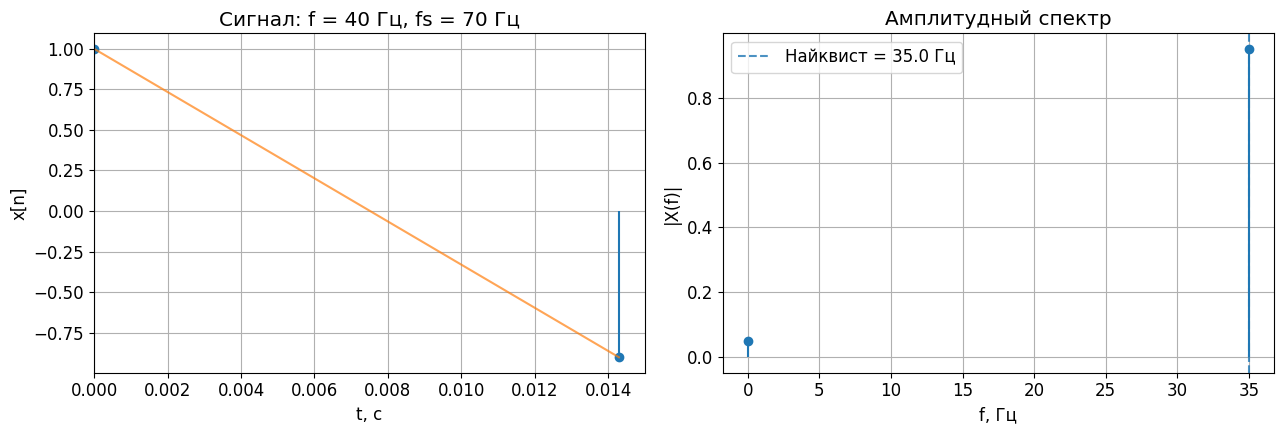

Частота сигнала: 40 Гц
Частота дискретизации: 70 Гц
Период сигнала: 0.02500 c
Число отсчётов на период: 2
Частота Найквиста: 35.00 Гц
Наблюдаемая частота (alias): 30.00 Гц
--------------------------------------------------------------------------------


In [4]:
for f_signal in [1, 40]:
    plot_case(f_signal, 70)
    print('-' * 80)


### Вывод для `fs = 70 Гц`

- Для **1 Гц** дискретизация всё ещё корректна.
- Для **40 Гц** условие теоремы нарушено.
- Вместо истинной частоты **40 Гц** после дискретизации наблюдается ложная частота:

\[
f_{alias} = |f - f_s| = |40 - 70| = 30 \text{ Гц}
\]

Именно поэтому в спектре появляется компонент около **30 Гц**, а не 40 Гц.


## Итоговый вывод

1. При **`fs = 400 Гц`** оба сигнала восстанавливаются корректно.  
2. При **`fs = 80 Гц`** сигнал **40 Гц** находится на границе Найквиста.  
3. При **`fs = 70 Гц`** для сигнала **40 Гц** возникает **aliasing**, и частота наблюдается как **30 Гц**.  

Это и демонстрирует практический смысл **теоремы Котельникова**:  
чтобы избежать искажений, частота дискретизации должна быть **не ниже удвоенной максимальной частоты сигнала**.


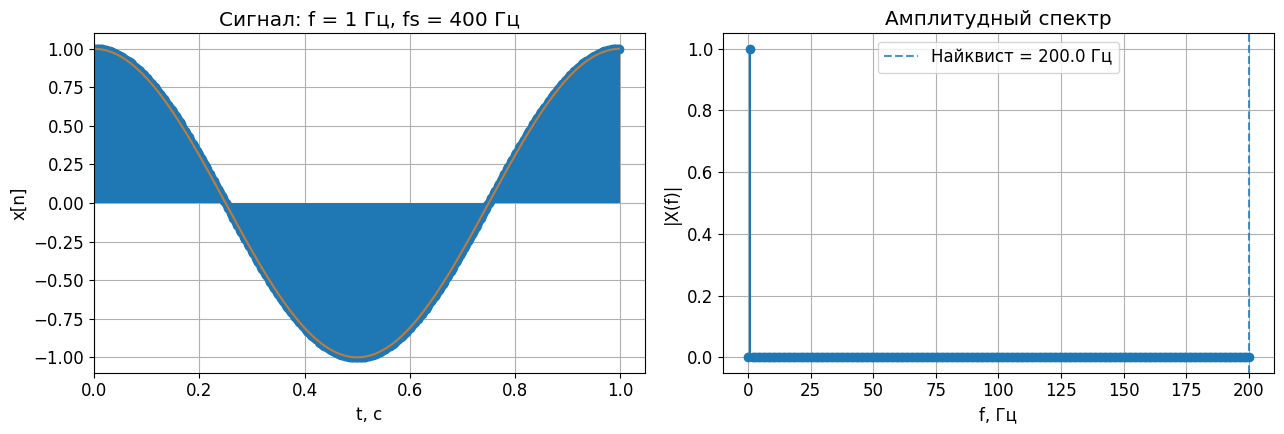

Частота сигнала: 1 Гц
Частота дискретизации: 400 Гц
Период сигнала: 1.00000 c
Число отсчётов на период: 400
Частота Найквиста: 200.00 Гц
Наблюдаемая частота (alias): 1.00 Гц


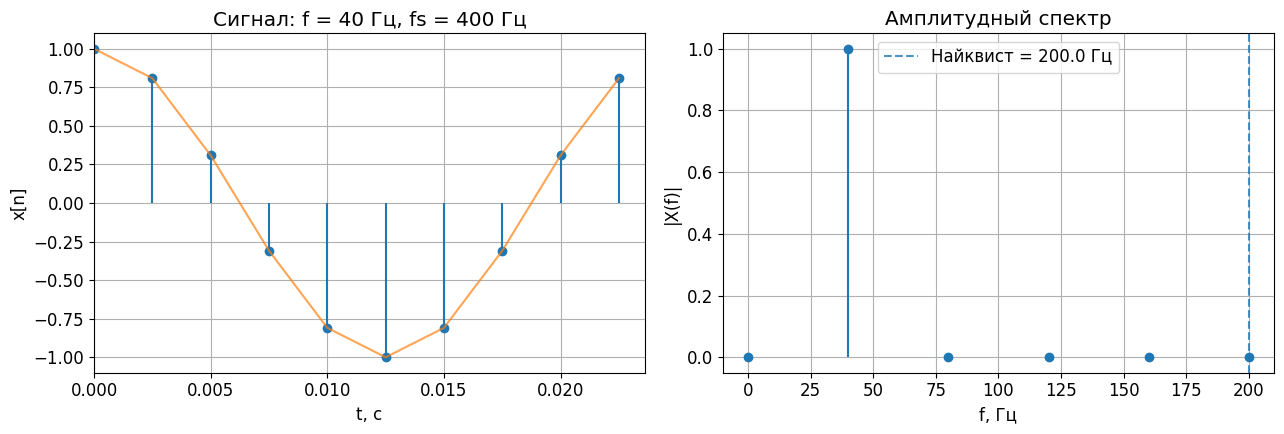

Частота сигнала: 40 Гц
Частота дискретизации: 400 Гц
Период сигнала: 0.02500 c
Число отсчётов на период: 10
Частота Найквиста: 200.00 Гц
Наблюдаемая частота (alias): 40.00 Гц


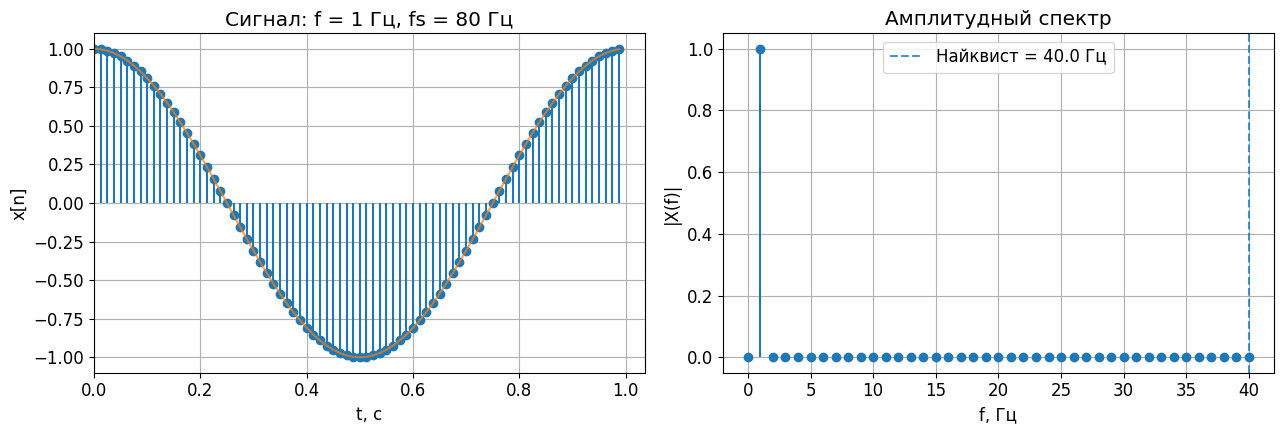

Частота сигнала: 1 Гц
Частота дискретизации: 80 Гц
Период сигнала: 1.00000 c
Число отсчётов на период: 80
Частота Найквиста: 40.00 Гц
Наблюдаемая частота (alias): 1.00 Гц


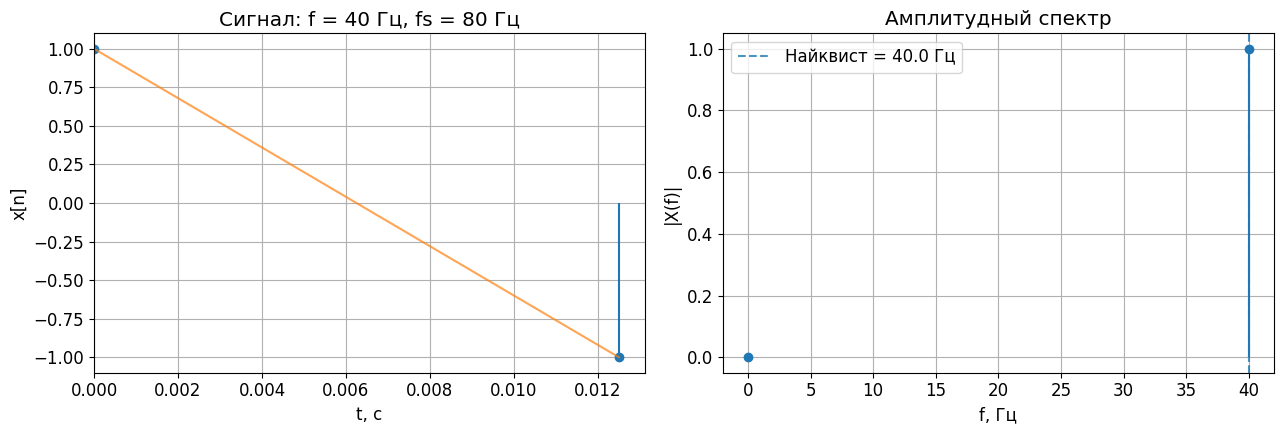

Частота сигнала: 40 Гц
Частота дискретизации: 80 Гц
Период сигнала: 0.02500 c
Число отсчётов на период: 2
Частота Найквиста: 40.00 Гц
Наблюдаемая частота (alias): 40.00 Гц


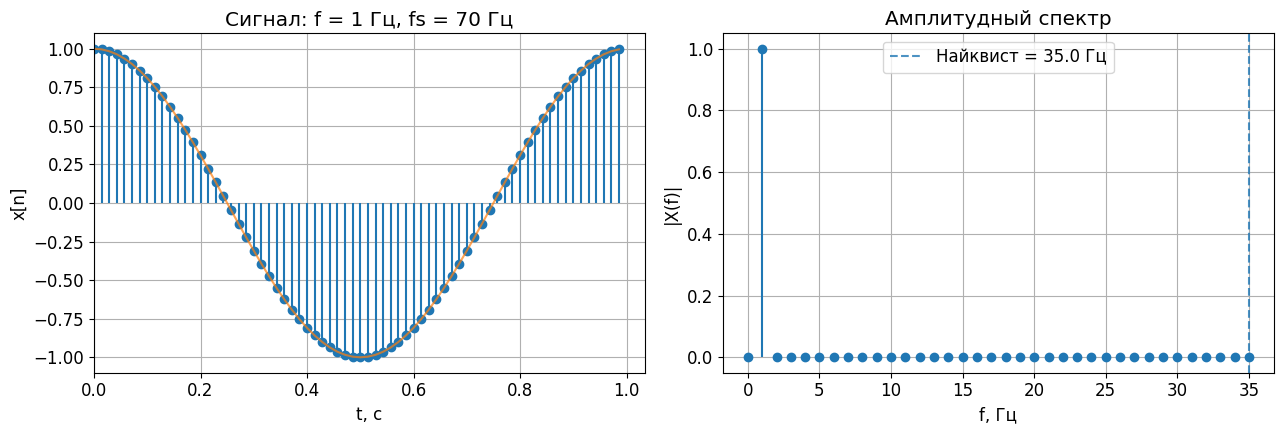

Частота сигнала: 1 Гц
Частота дискретизации: 70 Гц
Период сигнала: 1.00000 c
Число отсчётов на период: 70
Частота Найквиста: 35.00 Гц
Наблюдаемая частота (alias): 1.00 Гц


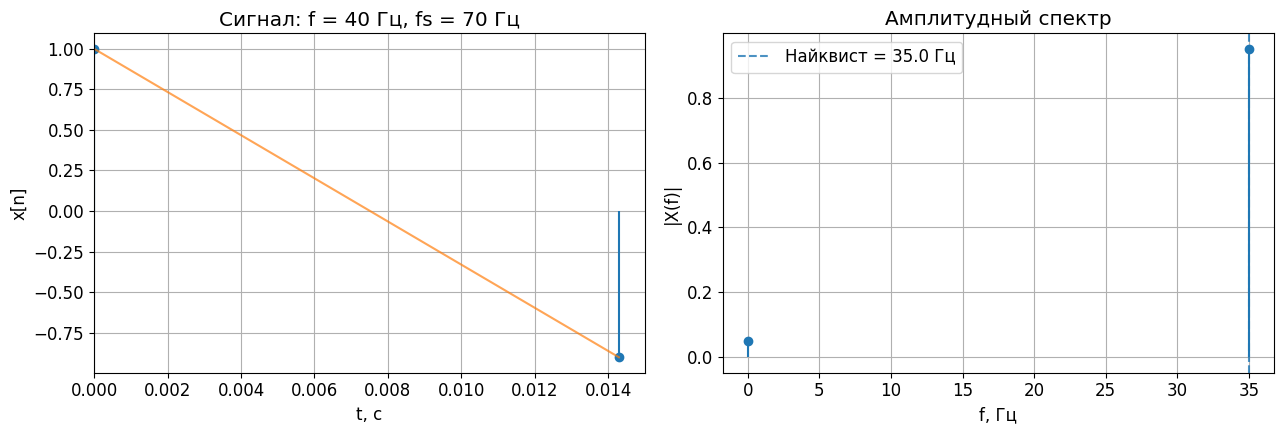

Частота сигнала: 40 Гц
Частота дискретизации: 70 Гц
Период сигнала: 0.02500 c
Число отсчётов на период: 2
Частота Найквиста: 35.00 Гц
Наблюдаемая частота (alias): 30.00 Гц


In [5]:
cases = [(1, 400), (40, 400), (1, 80), (40, 80), (1, 70), (40, 70)]

for f_signal, fs in cases:
    plot_case(f_signal, fs)
    print('=' * 100)
